In [2]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
import pickle 

## Setup and Preprocessing image

In [3]:
def display_image(image):
  
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()
   

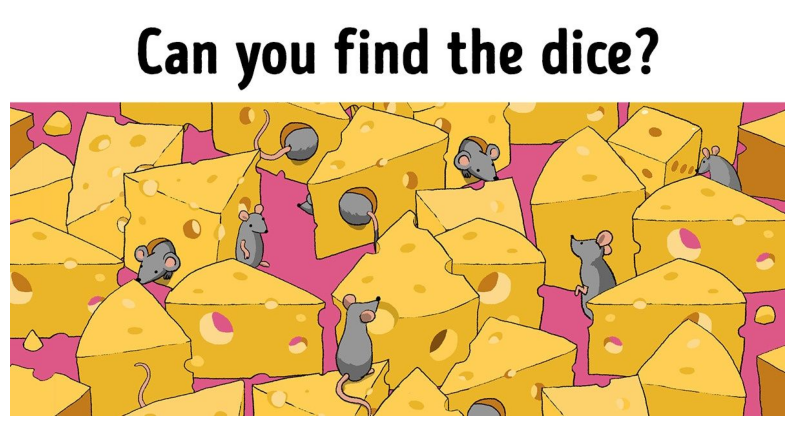

In [4]:
image_path = "mouse.jpg"
image = cv2.imread(image_path)
display_image(image)


In [5]:
# cắt bỏ vùng trắng và chữ trong ảnh 

def crop_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x, y, w, h = cv2.boundingRect(contours[0])
    cropped_image = image[y:y+h, x:x+w]
    return cropped_image

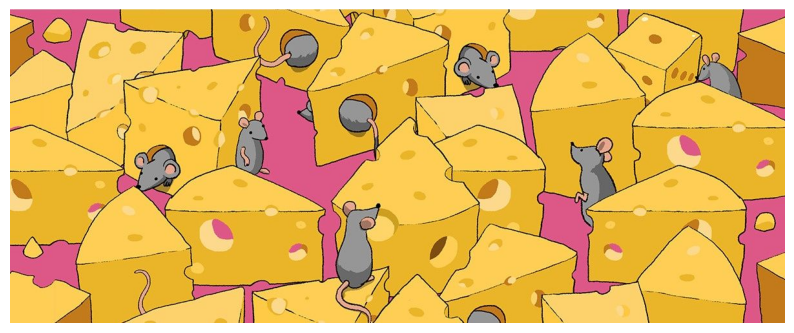

In [6]:
cropped_image = crop_image(image)
display_image(cropped_image)

# Appoarch 1:  Nhận dạng vùng màu xám của chuột và vùng đuôi hồng của chuột

- Ý tưởng : 
     1. Nhận dạng vùng màu xám của chuột + kết hợp với vùng đuôi chuột (sử dụng masking 2 lần cho 2 vùng và dùng phép toán Union để hợp lại tìm mask phù hợp)



## 1. Tìm 2 khoảng màu 

### Sử dụng mô hình Clustering

- Xác định chính xác các các vùng màu của đuôi chuột, vùng màu xám, vùng màu nền và vùng màu phomat

In [7]:
# from sklearn.cluster import KMeans 

# hsv_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)
# hsv_image.shape

In [8]:
# hsv_image =  hsv_image.reshape(-1, 3)

In [9]:
# hsv_image

In [10]:
# num_cluster = 4
# kmeans = KMeans(n_clusters=num_cluster, random_state=42, n_init = 10, max_iter=300)
# label =  kmeans.fit_predict(hsv_image)

In [11]:
# centroids = kmeans.cluster_centers_.astype(int) 
# cluster_range = {}


# for i in range(num_cluster):
    
#     cluster_pixels = hsv_image[label == i]
#     min_h, min_s, min_v = np.min(cluster_pixels, axis=0)
#     max_h, max_s, max_v = np.max(cluster_pixels, axis=0)
    
#     cluster_range[i] = {
#         'min': (min_h, min_s, min_v),
#         'max': (max_h, max_s, max_v),
#         'center': centroids[i]
#     }
    
#     mean_color_hsv = np.uint8([[centroids[i]]])
#     mean_color_rgb = cv2.cvtColor(mean_color_hsv, cv2.COLOR_HSV2RGB)
    
#     max_color_hsv = np.uint8([[[max_h, max_s, max_v]]])
#     max_color_rgb = cv2.cvtColor(max_color_hsv, cv2.COLOR_HSV2RGB)

#     min_color_hsv = np.uint8([[[min_h, min_s, min_v]]])
#     min_color_rgb = cv2.cvtColor(min_color_hsv, cv2.COLOR_HSV2RGB)

#     # Create a figure with 3 subplots in a row
#     plt.figure(figsize=(9, 3))
    
#     plt.subplot(1, 3, 1)
#     plt.imshow([[mean_color_rgb[0][0]]])
#     plt.title("Mean Color")
#     plt.axis('off')
    
#     plt.subplot(1, 3, 2)
#     plt.imshow([[max_color_rgb[0][0]]])
#     plt.title("Max Color")
#     plt.axis('off')
    
#     plt.subplot(1, 3, 3)
#     plt.imshow([[min_color_rgb[0][0]]])
#     plt.title("Min Color")
#     plt.axis('off')
    
#     plt.tight_layout()
#     plt.title(f'Cluster {i}\nH: {min_h}-{max_h}\nS: {min_s}-{max_s}\nV: {min_v}-{max_v}')
#     plt.axis('off')
#     plt.show()

    


### Sử dụng phương pháp thủ công 

**Cách 1**:  Lấy sample trực tiếp các màu thuộc vùng đuôi của chuột

In [12]:
sample_pixel = []

def click_event(event, x, y,  flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        pixel = cropped_image[y, x]
        pixel_hsv = cv2.cvtColor(np.uint8([[pixel]]), cv2.COLOR_BGR2HSV)[0][0]
        print(f"Clicked pixel: BGR: {pixel}, HSV: {pixel_hsv}")
        sample_pixel.append(pixel_hsv)


# cv2.imshow("Image", cropped_image)
# cv2.setMouseCallback("Image", click_event)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [13]:
# with open ('sample_pixel.pkl', 'wb') as f:
#     pickle.dump(sample_pixel, f)

- load các sample đã được chọn và tính khoảng min và max cho từng h, s, v 

In [14]:
with open('sample_pixel_data.pkl', 'rb') as f:
    sample_pixel = pickle.load(f)

print("Sample pixel data loaded from file with length:", len(sample_pixel))
sample_pixel = np.array(sample_pixel)

Sample pixel data loaded from file with length: 275


In [15]:
min_h = np.min(sample_pixel, axis=0)[0]
max_h = np.max(sample_pixel, axis=0)[0]

max_s = np.max(sample_pixel, axis=0)[1]
min_s = np.min(sample_pixel, axis=0)[1]

max_v = np.max(sample_pixel, axis=0)[2]
min_v = np.min(sample_pixel, axis=0)[2]


print(f"HSV values range : S: {min_s} - {max_s}")
print(f"HSV values range : V: {min_v} - {max_v}") 
print(f"HSV values range : H: {min_h} - {max_h}")

HSV values range : S: 46 - 255
HSV values range : V: 53 - 255
HSV values range : H: 0 - 18


**Cách 2** sử dụng miền ROI để chọn màu

In [16]:
# # lựa chọn vùng ROI để trích xuất thông tin hình ảnh 
# hsv_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)
# roi = cv2.selectROI("Select ROI", image, showCrosshair=True, fromCenter=False)
# x, y, w, h = roi
# cv2.destroyAllWindows()

In [17]:
# roi 

In [18]:
# roi_hsv = hsv_image[y:y+h, x:x+w]
# h_min, s_min, v_min = np.min(roi_hsv, axis=(0, 1))
# h_max, s_max, v_max = np.max(roi_hsv, axis=(0, 1))

In [19]:
# print(f"ROI HSV Range: H: {h_min}-{h_max}, S: {s_min}-{s_max}, V: {v_min}-{v_max}")

## 2. Sử dụng mask trên cả vùng lông và đuôi tìm được

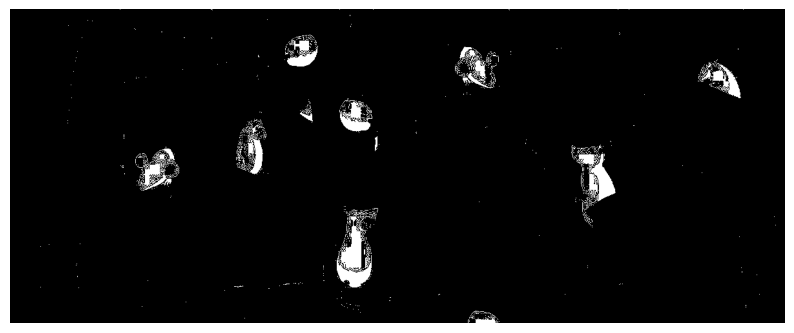

In [20]:
hsv = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)

lower_gray = np.array([0, 0, 40], dtype=np.uint8)
upper_gray = np.array([180, 120, 150], dtype=np.uint8)
fur_mask = cv2.inRange(hsv, lower_gray, upper_gray)

display_image(fur_mask)

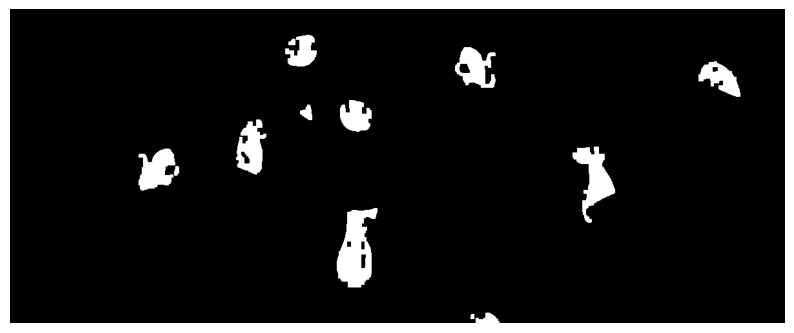

In [21]:
kernel = np.ones((5, 5), np.uint8)
fur_mask = cv2.morphologyEx(fur_mask, cv2.MORPH_CLOSE, kernel)
fur_mask = cv2.morphologyEx(fur_mask, cv2.MORPH_OPEN, kernel)

display_image(fur_mask)

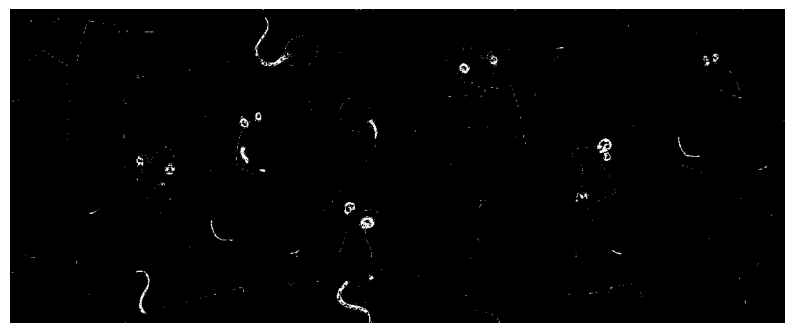

In [22]:
lower_pink = np.array([7, 46, 53], dtype=np.uint8)
upper_pink = np.array([18, 100, 255], dtype=np.uint8)
tail_mask = cv2.inRange(hsv, lower_pink, upper_pink)

display_image(tail_mask)

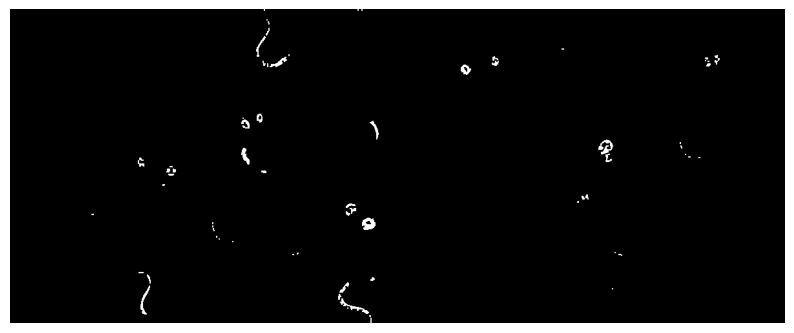

In [23]:
kernel = np.ones((2, 2), np.uint8)
tail_mask = cv2.morphologyEx(tail_mask, cv2.MORPH_CLOSE, kernel)
tail_mask = cv2.morphologyEx(tail_mask, cv2.MORPH_OPEN, kernel)

display_image(tail_mask)

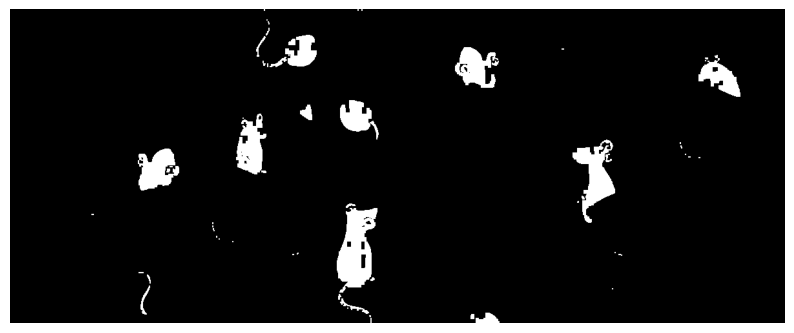

In [24]:
# phép hợp giữa 2 ảnh binary 
union_mask = cv2.bitwise_or(fur_mask, tail_mask)
display_image(union_mask) 

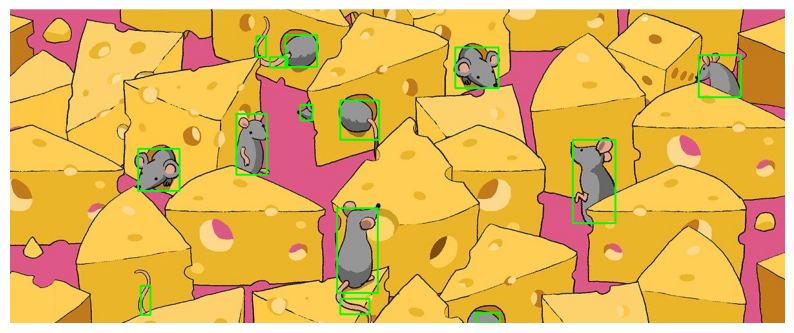

In [25]:
contours, _ = cv2.findContours(union_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if w > 10 and h > 10:
        x, y, w, h = cv2.boundingRect(contour)
        cropped_image =  cv2.rectangle(cropped_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

display_image(cropped_image)

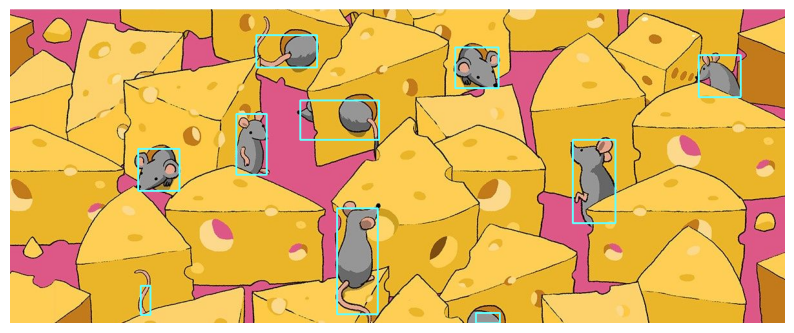

In [ ]:
rect_box = []
contours, _ = cv2.findContours(union_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    if w > 10 and h > 10: 
        rect_box.append((x, y, w, h))



def expand_box(box, expand_by=10):
    x, y, w, h = box
    x = max(0, x - expand_by)
    y = max(0, y - expand_by)
    w = w + 2 * expand_by
    h = h + 2 * expand_by
    return (x, y, w, h)

def is_overlapping(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min, y1_min = x1, y1
    x1_max, y1_max = x1 + w1, y1 + h1
    x2_min, y2_min = x2, y2
    x2_max, y2_max = x2 + w2, y2 + h2
    if x1_max < x2_min or x2_max < x1_min:
        return False
    if y1_max < y2_min or y2_max < y1_min:
        return False
    return True

def merge_boxes(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    x_min = min(x1, x2)
    y_min = min(y1, y2)
    x_max = max(x1 + w1, x2 + w2)
    y_max = max(y1 + h1, y2 + h2)
    
    return (x_min, y_min, x_max - x_min, y_max - y_min)

def merge_nearby_boxes(rect_box, expand_by=10):
    # Mở rộng các hộp
    expanded_boxes = [expand_box(box, expand_by) for box in rect_box]
    
    # Danh sách các hộp đã gộp
    merged_boxes = []
    used = [False] * len(rect_box)
    
    for i in range(len(rect_box)):
        if used[i]:
            continue
        
        current_box = rect_box[i]
        used[i] = True
        
        for j in range(i + 1, len(rect_box)):
            if used[j]:
                continue
            
            if is_overlapping(expanded_boxes[i], expanded_boxes[j]):
                current_box = merge_boxes(current_box, rect_box[j])
                used[j] = True
        
        merged_boxes.append(current_box)
    
    return merged_boxes

merged_boxes = merge_nearby_boxes(rect_box, expand_by=25)

new_image = cv2.imread(image_path)
new_cropped_image = crop_image(new_image)

for box in merged_boxes:
    x, y, w, h = box
    cv2.rectangle(new_cropped_image, (x, y), (x + w, y + h), (255, 255 , 100), 2)

display_image(new_cropped_image)


In [29]:
print("Number of mouses:", len(merged_boxes))

Number of mouses: 10
